# ResNet-18 — Deepfake Detection (PyTorch + CUDA 12.8)
Binarny klasyfikator **real / fake** oparty na pretrenowanym ResNet-18 z torchvision.  
Trening odbywa się na GPU (CUDA 12.8). Dane muszą znajdować się w katalogu `whole/`.


## 1. Import bibliotek


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
import time
import copy

print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")


PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128


## 2. Sprawdzenie GPU i CUDA


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU dostępne: {torch.cuda.get_device_name(0)}")
    print(f"CUDA wersja: {torch.version.cuda}")
    print(f"Liczba GPU: {torch.cuda.device_count()}")
    print(f"Pamięć GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    device = torch.device("cpu")
    print("CUDA niedostępne — trening na CPU (wolno!)")
    print("Upewnij się, że masz zainstalowany PyTorch z CUDA 12.8:")
    print("  pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128")

print(f"\nUrządzenie: {device}")


GPU dostępne: NVIDIA GeForce RTX 5060 Ti
CUDA wersja: 12.8
Liczba GPU: 1
Pamięć GPU: 17.10 GB

Urządzenie: cuda


## 3. Konfiguracja ścieżek i hiperparametrów


In [3]:
# --- Ścieżki danych ---
DATA_ROOT   = "whole"
TRAIN_DIR   = os.path.join(DATA_ROOT, "train")
VAL_DIR     = os.path.join(DATA_ROOT, "val")
TEST_DIR    = os.path.join(DATA_ROOT, "test")

# --- Hiperparametry ---
BATCH_SIZE  = 256        # 16 GB VRAM — ResNet-18 faza 2 zajmie ~8–10 GB
                          # jeśli OOM: zmniejsz do 128
NUM_EPOCHS  = 20
LR          = 1e-4
NUM_CLASSES = 2           # real / fake
IMG_SIZE    = 224         # wymagane przez ResNet
NUM_WORKERS = 8           # więcej wątków dla szybszego ładowania danych

print(f"Train: {TRAIN_DIR}")
print(f"Val:   {VAL_DIR}")
print(f"Test:  {TEST_DIR}")
print(f"\nBATCH_SIZE={BATCH_SIZE}  NUM_WORKERS={NUM_WORKERS}")


Train: whole\train
Val:   whole\val
Test:  whole\test

BATCH_SIZE=256  NUM_WORKERS=8


## 4. Transformacje i DataLoadery

Struktura katalogów zakłada, że `ImageFolder` mapuje podkatalogi na klasy.  
Nazwy klas zostaną ustalone automatycznie (alfabetycznie), więc `fake=0`, `real=1`.


In [4]:
# Statystyki ImageNet (standardowe dla pretrenowanych modeli)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# --- Datasety ---
train_dataset = ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset   = ImageFolder(root=VAL_DIR,   transform=val_test_transforms)
test_dataset  = ImageFolder(root=TEST_DIR,  transform=val_test_transforms)

print("Klasy (train):", train_dataset.classes)
print("Klasy (val):  ", val_dataset.classes)
print("Klasy (test): ", test_dataset.classes)
print(f"\nRozmiary: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")

# --- DataLoadery ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)


Klasy (train): ['fake', 'real']
Klasy (val):   ['valid_fake', 'valid_real']
Klasy (test):  ['test_fake', 'test_real']

Rozmiary: train=6347, val=643, test=832


## 5. Podgląd próbki danych


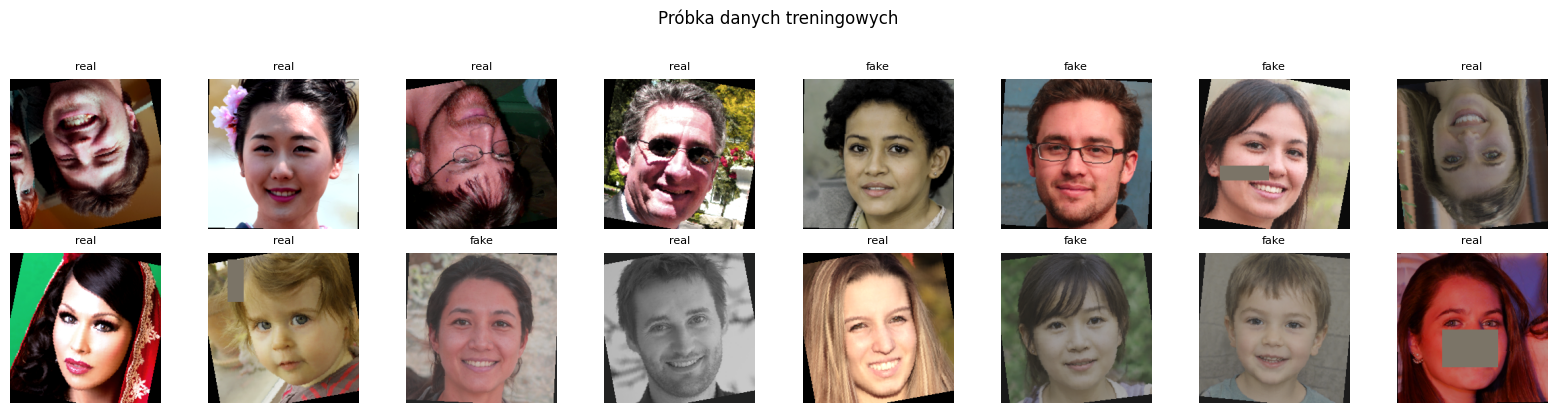

In [5]:
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    t = tensor.clone()
    for c, m, s in zip(range(3), mean, std):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

images, labels = next(iter(train_loader))
class_names = train_dataset.classes

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        img = denormalize(images[i]).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(class_names[labels[i]], fontsize=8)
    ax.axis("off")
plt.suptitle("Próbka danych treningowych", y=1.02)
plt.tight_layout()
plt.show()


## 6. Model ResNet-18 — fine-tuning


In [6]:
# Załaduj pretrenowany ResNet-18 (wagi ImageNet)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Podmień ostatnią warstwę FC na klasyfikator binarny
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features, NUM_CLASSES),
)

# --- FAZA 1: Zamroź cały backbone, trenuj tylko FC ---
# Pozwala to uniknąć overfittingu na początku treningu
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

# Przenieś model na GPU
model = model.to(device)

def count_params(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_params(model)
print(f"Parametry łącznie:     {total_params:,}")
print(f"Parametry trenowalne:  {trainable_params:,}  (tylko FC — faza 1)")
print(f"Model na urządzeniu:   {next(model.parameters()).device}")


Parametry łącznie:     11,177,538
Parametry trenowalne:  1,026  (tylko FC — faza 1)
Model na urządzeniu:   cuda:0


## 7. Funkcja straty, optymalizator i scheduler


In [8]:
# --- Parametry treningu dwufazowego ---
PHASE1_EPOCHS   = 5       # epoki z zamrożonym backbonem
PHASE2_EPOCHS   = 15      # epoki z odmrożonym backbonem (fine-tuning)
NUM_EPOCHS      = PHASE1_EPOCHS + PHASE2_EPOCHS

LR_PHASE1       = 1e-3    # wyższy LR — trenujemy tylko FC
LR_PHASE2       = 1e-5    # bardzo niski LR — fine-tuning całego modelu
PATIENCE        = 5       # early stopping: ile epok bez poprawy val_acc

criterion = nn.CrossEntropyLoss()

# Optimizer startuje z ustawieniami fazy 1 (tylko FC)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1, weight_decay=1e-4
)

# ReduceLROnPlateau reaguje na plateau val_loss
scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.3, patience=3
)

print(f"Faza 1: {PHASE1_EPOCHS} epok  (backbone zamrożony, LR={LR_PHASE1:.0e})")
print(f"Faza 2: {PHASE2_EPOCHS} epok  (full fine-tuning, LR={LR_PHASE2:.0e})")
print(f"Early stopping patience: {PATIENCE} epok")


Faza 1: 5 epok  (backbone zamrożony, LR=1e-03)
Faza 2: 15 epok  (full fine-tuning, LR=1e-05)
Early stopping patience: 5 epok


## 8. Pętla treningowa


In [9]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc   = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0
phase2_started    = False

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    # --- Przejście do fazy 2 ---
    if epoch == PHASE1_EPOCHS and not phase2_started:
        print("\n" + "=" * 55)
        print("  FAZA 2: odmrażam backbone — full fine-tuning")
        print("=" * 55)
        for param in model.parameters():
            param.requires_grad = True
        # Reset optimizera z niskim LR dla całej sieci
        optimizer = optim.Adam(model.parameters(), lr=LR_PHASE2, weight_decay=1e-4)
        scheduler = lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.3, patience=3
        )
        phase2_started = True
        _, trainable = count_params(model)
        print(f"  Parametry trenowalne: {trainable:,}\n")

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"\nEpoka {epoch+1}/{NUM_EPOCHS}  "
          f"({'Faza1' if epoch < PHASE1_EPOCHS else 'Faza2'}, LR={current_lr:.2e})")
    print("-" * 55)

    for phase in ("train", "val"):
        if phase == "train":
            model.train()
            loader = train_loader
        else:
            model.eval()
            loader = val_loader

        running_loss    = 0.0
        running_correct = 0

        for inputs, labels_batch in loader:
            inputs       = inputs.to(device, non_blocking=True)
            labels_batch = labels_batch.to(device, non_blocking=True)

            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == "train"):
                outputs = model(inputs)
                loss    = criterion(outputs, labels_batch)
                preds   = outputs.argmax(dim=1)
                if phase == "train":
                    loss.backward()
                    optimizer.step()

            running_loss    += loss.item() * inputs.size(0)
            running_correct += (preds == labels_batch).sum().item()

        ds_size    = len(train_dataset) if phase == "train" else len(val_dataset)
        epoch_loss = running_loss / ds_size
        epoch_acc  = running_correct / ds_size

        history[f"{phase}_loss"].append(epoch_loss)
        history[f"{phase}_acc"].append(epoch_acc)
        print(f"  {phase.upper():5s}  loss={epoch_loss:.4f}  acc={epoch_acc:.4f}")

        if phase == "val":
            scheduler.step(epoch_loss)   # ReduceLROnPlateau na val_loss

            if epoch_acc > best_val_acc:
                best_val_acc      = epoch_acc
                best_model_wts    = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
                torch.save(best_model_wts, "resnet18_best.pth")
                print(f"  *** Nowy najlepszy model zapisany (acc={best_val_acc:.4f}) ***")
            else:
                epochs_no_improve += 1
                print(f"  (brak poprawy: {epochs_no_improve}/{PATIENCE})")

    print(f"  Czas epoki: {time.time() - epoch_start:.1f}s")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping po epoce {epoch+1} (brak poprawy przez {PATIENCE} epok).")
        break

# Załaduj najlepsze wagi
model.load_state_dict(best_model_wts)
print(f"\nTrening zakończony. Najlepsza walidacyjna acc: {best_val_acc:.4f}")



Epoka 1/20  (Faza1, LR=1.00e-03)
-------------------------------------------------------
  TRAIN  loss=0.6666  acc=0.6368
  VAL    loss=0.5938  acc=0.6827
  *** Nowy najlepszy model zapisany (acc=0.6827) ***
  Czas epoki: 73.5s

Epoka 2/20  (Faza1, LR=1.00e-03)
-------------------------------------------------------
  TRAIN  loss=0.4866  acc=0.7730
  VAL    loss=0.5991  acc=0.6874
  *** Nowy najlepszy model zapisany (acc=0.6874) ***
  Czas epoki: 70.8s

Epoka 3/20  (Faza1, LR=1.00e-03)
-------------------------------------------------------
  TRAIN  loss=0.4319  acc=0.8038
  VAL    loss=0.6120  acc=0.6858
  (brak poprawy: 1/5)
  Czas epoki: 71.0s

Epoka 4/20  (Faza1, LR=1.00e-03)
-------------------------------------------------------
  TRAIN  loss=0.4093  acc=0.8131
  VAL    loss=0.6472  acc=0.6765
  (brak poprawy: 2/5)
  Czas epoki: 70.6s

Epoka 5/20  (Faza1, LR=1.00e-03)
-------------------------------------------------------
  TRAIN  loss=0.3927  acc=0.8199
  VAL    loss=0.6331  a

## 9. Ewaluacja na zbiorze testowym


Test accuracy: 0.6923

              precision    recall  f1-score   support

   test_fake       0.74      0.59      0.66       416
   test_real       0.66      0.79      0.72       416

    accuracy                           0.69       832
   macro avg       0.70      0.69      0.69       832
weighted avg       0.70      0.69      0.69       832



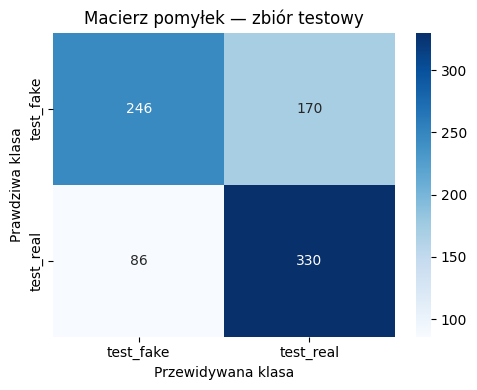

In [10]:
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels_batch in test_loader:
        inputs = inputs.to(device, non_blocking=True)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"Test accuracy: {test_acc:.4f}\n")
print(classification_report(all_labels, all_preds,
                             target_names=test_dataset.classes))

# Macierz pomyłek
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes, ax=ax)
ax.set_xlabel("Przewidywana klasa")
ax.set_ylabel("Prawdziwa klasa")
ax.set_title("Macierz pomyłek — zbiór testowy")
plt.tight_layout()
plt.show()


## 10. Wizualizacja krzywych uczenia


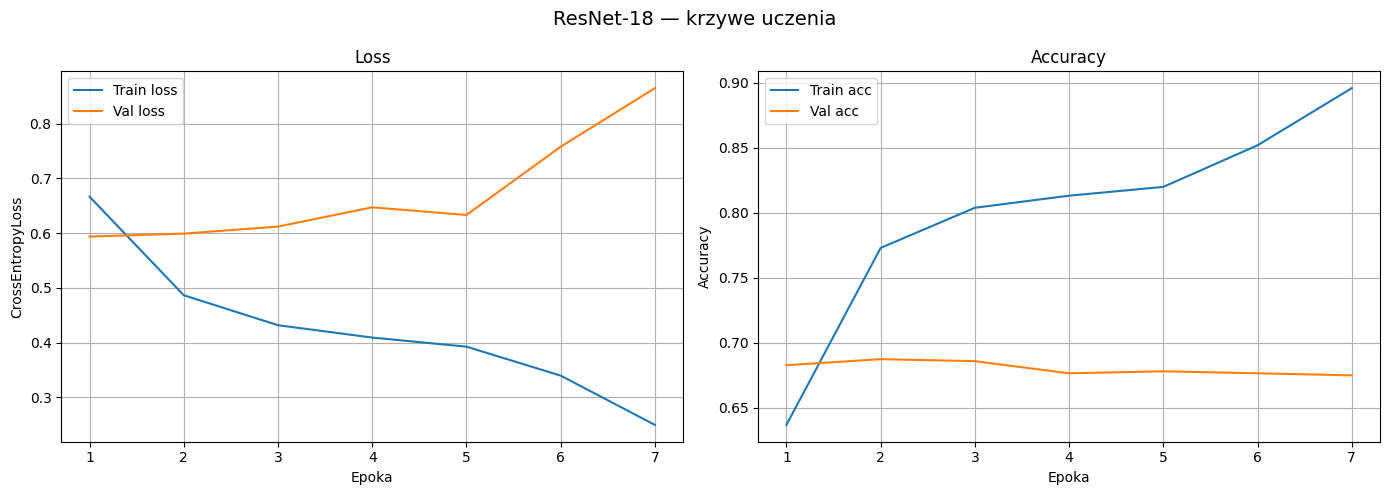

In [12]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history["train_loss"], label="Train loss")
ax1.plot(epochs_range, history["val_loss"],   label="Val loss")
ax1.set_title("Loss")
ax1.set_xlabel("Epoka")
ax1.set_ylabel("CrossEntropyLoss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, history["train_acc"], label="Train acc")
ax2.plot(epochs_range, history["val_acc"],   label="Val acc")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoka")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.suptitle("ResNet-18 — krzywe uczenia", fontsize=14)
plt.tight_layout()
plt.show()


## 11. Przykładowe predykcje ze zbioru testowego


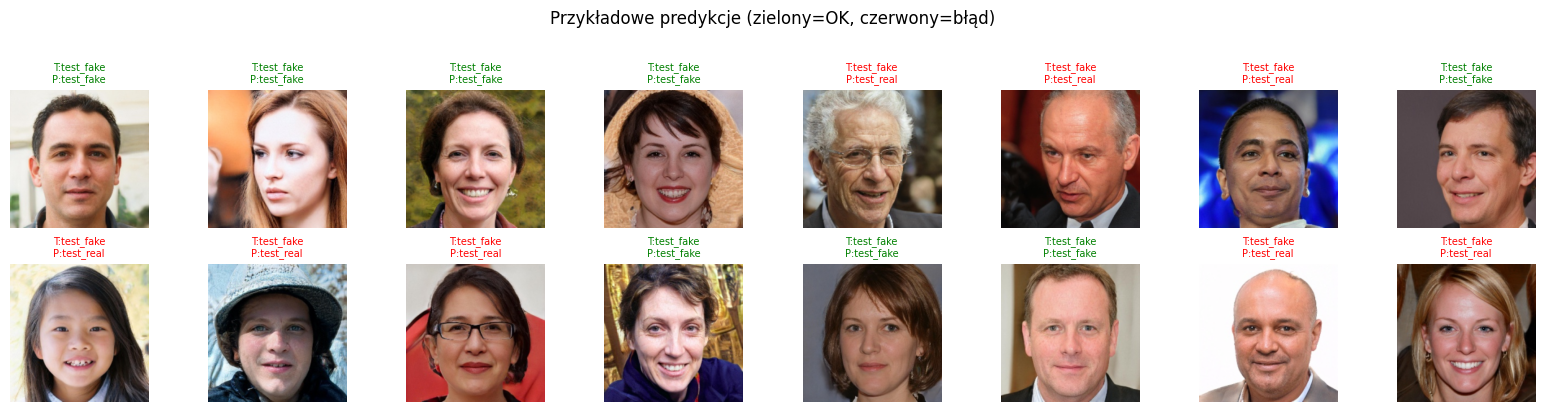

In [13]:
model.eval()
sample_imgs, sample_labels = next(iter(test_loader))
sample_imgs_gpu = sample_imgs.to(device)

with torch.no_grad():
    sample_outputs = model(sample_imgs_gpu)
    sample_preds = sample_outputs.argmax(dim=1).cpu()

class_names = test_dataset.classes
n = min(16, len(sample_imgs))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i, ax in enumerate(axes.flat):
    if i >= n:
        ax.axis("off")
        continue
    img = denormalize(sample_imgs[i]).permute(1, 2, 0).numpy()
    true_lbl = class_names[sample_labels[i]]
    pred_lbl = class_names[sample_preds[i]]
    color = "green" if true_lbl == pred_lbl else "red"
    ax.imshow(img)
    ax.set_title(f"T:{true_lbl}\nP:{pred_lbl}", fontsize=7, color=color)
    ax.axis("off")

plt.suptitle("Przykładowe predykcje (zielony=OK, czerwony=błąd)", y=1.02)
plt.tight_layout()
plt.show()
